In [ ]:
# 確保先安裝
!pip install roboflow
#!pip uninstall -y Pillow pillow-heif # 先卸載，避免衝突
#!pip install Pillow==9.5.0 pillow-heif # 重新安裝 Pillow 9.5.0 和 pillow-heif (如果 roboflow 需要)
from roboflow import Roboflow
import os

# --- Roboflow 配置 ---

ROBOFLOW_API_KEY = "immWNYskFu6rFSgXO3fa"  # <--- 替換成你的 API KEY
WORKSPACE_ID = "tyler-yonjx"     # <--- 替換成你的 Workspace ID
PROJECT_ID = "car-colors-1smyc"         # <--- 替換成你的 Project ID
VERSION_NUMBER = 5                     # <--- 替換成你想下載的版本號

if not ROBOFLOW_API_KEY or ROBOFLOW_API_KEY == "immWNYskFu6rFSgXO3fa":
    print("錯誤：請先設定你的 Roboflow API Key！")
    # exit() # 或者引導用戶輸入

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace(WORKSPACE_ID).project(PROJECT_ID)
version = project.version(VERSION_NUMBER)
dataset = version.download("folder") # 下載為資料夾結構

# dataset.location 包含了下載數據集的根目錄路徑
downloaded_dataset_path = dataset.location
print(f"數據集已下載到: {downloaded_dataset_path}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.7/86.7 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 62.2 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.11.0.86
    Uninstalling opencv-python-headless-4.11.0.86:
      Successfully uninstalled opencv-python-headless-4.11.0.86
  Attempting uninstall: idna
    Found existing installation: idna 3.10
    Uninstalling idna-3.10:
      Successfully uninstalled idna-3.10
錯誤：請先設定你的 Roboflow API Key！
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Car-Colors-5 in folder:: 100%|██████████| 2036/2036 [00:00<00:00, 5348.12it/s]

數據集已下載到: /content/Car-Colors-5


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator # <--- 確保這行存在且正確
# from roboflow import Roboflow # 如果你還在使用 roboflow
import numpy as np
import matplotlib.pyplot as plt
import os
import math
base_dir = downloaded_dataset_path # <--- 使用 Roboflow 下載的路徑
train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'valid') # Roboflow 通常使用 'valid' 而不是 'validation'
test_dir = os.path.join(base_dir, 'test')

img_height = 224
img_width = 224
batch_size = 16
# num_classes 會從 train_generator 自動獲取
epochs = 20

# --- 後續的 ImageDataGenerator, 模型定義, 編譯, 訓練程式碼 ---
# ... (與你之前的程式碼相同，只是 base_dir 更新了) ...

# 例如，創建 ImageDataGenerator
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

if not os.path.exists(train_dir):
    print(f"錯誤：訓練資料夾 {train_dir} 不存在。請檢查 Roboflow 下載的結構或路徑。")
    # exit()

print(f"Loading training data from: {train_dir}")
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

# 檢查 'valid' 資料夾是否存在
if not os.path.exists(validation_dir):
    print(f"警告：驗證資料夾 {validation_dir} 不存在。可能 Roboflow 版本中沒有 'valid' 集。")
    validation_generator = None
else:
    print(f"Loading validation data from: {validation_dir}")
    validation_generator = val_test_datagen.flow_from_directory(
        validation_dir,
        target_size=(img_height, img_width),
        batch_size=batch_size,
        class_mode='categorical',
        shuffle=False
    )

# 檢查 'test' 資料夾是否存在
if not os.path.exists(test_dir):
    print(f"警告：測試資料夾 {test_dir} 不存在。可能 Roboflow 版本中沒有 'test' 集。")
    test_generator = None
else:
    print(f"Loading test data from: {test_dir}")
    test_generator = val_test_datagen.flow_from_directory(
        test_dir,
        target_size=(img_height, img_width),
        batch_size=batch_size,
        class_mode='categorical',
        shuffle=False
    )
num_classes = train_generator.num_classes
class_indices = train_generator.class_indices
print(f"Found {train_generator.samples} images belonging to {num_classes} classes for training.")
print(f"Class labels: {list(class_indices.keys())}")
print(f"Class indices: {class_indices}")
if validation_generator:
    print(f"Found {validation_generator.samples} images for validation.")
if test_generator:
    print(f"Found {test_generator.samples} images for testing.")


Loading training data from: /content/Car-Colors-5/train
Found 1396 images belonging to 9 classes.
Loading validation data from: /content/Car-Colors-5/valid
Found 395 images belonging to 9 classes.
Loading test data from: /content/Car-Colors-5/test
Found 213 images belonging to 9 classes.
Found 1396 images belonging to 9 classes for training.
Class labels: ['Black', 'Blue', 'Green', 'Grey', 'Orange', 'Red', 'Silver', 'White', 'Yellow']
Class indices: {'Black': 0, 'Blue': 1, 'Green': 2, 'Grey': 3, 'Orange': 4, 'Red': 5, 'Silver': 6, 'White': 7, 'Yellow': 8}
Found 395 images for validation.
Found 213 images for testing.


In [ ]:
# --- 定義 VGG19 模型 ---
model = Sequential(name=f'VGG19_Roboflow_{num_classes}Classes')

model.add(Conv2D(64, (3, 3), activation='relu', padding='same', name='block1_conv1', input_shape=(img_height, img_width, 3)))
model.add(Conv2D(64, (3, 3), activation='relu', padding='same', name='block1_conv2'))
model.add(MaxPooling2D((2, 2), strides=(2, 2), name='block1_pool'))

model.add(Conv2D(128, (3, 3), activation='relu', padding='same', name='block2_conv1'))
model.add(Conv2D(128, (3, 3), activation='relu', padding='same', name='block2_conv2'))
model.add(MaxPooling2D((2, 2), strides=(2, 2), name='block2_pool'))

model.add(Conv2D(256, (3, 3), activation='relu', padding='same', name='block3_conv1'))
model.add(Conv2D(256, (3, 3), activation='relu', padding='same', name='block3_conv2'))
model.add(Conv2D(256, (3, 3), activation='relu', padding='same', name='block3_conv3'))
model.add(Conv2D(256, (3, 3), activation='relu', padding='same', name='block3_conv4'))
model.add(MaxPooling2D((2, 2), strides=(2, 2), name='block3_pool'))

model.add(Conv2D(512, (3, 3), activation='relu', padding='same', name='block4_conv1'))
model.add(Conv2D(512, (3, 3), activation='relu', padding='same', name='block4_conv2'))
model.add(Conv2D(512, (3, 3), activation='relu', padding='same', name='block4_conv3'))
model.add(Conv2D(512, (3, 3), activation='relu', padding='same', name='block4_conv4'))
model.add(MaxPooling2D((2, 2), strides=(2, 2), name='block4_pool'))

model.add(Conv2D(512, (3, 3), activation='relu', padding='same', name='block5_conv1'))
model.add(Conv2D(512, (3, 3), activation='relu', padding='same', name='block5_conv2'))
model.add(Conv2D(512, (3, 3), activation='relu', padding='same', name='block5_conv3'))
model.add(Conv2D(512, (3, 3), activation='relu', padding='same', name='block5_conv4'))
model.add(MaxPooling2D((2, 2), strides=(2, 2), name='block5_pool'))

model.add(Flatten(name='flatten'))
model.add(Dense(4096, activation='relu', name='fc1'))
model.add(Dropout(0.5, name='dropout1'))
model.add(Dense(4096, activation='relu', name='fc2'))
model.add(Dropout(0.5, name='dropout2'))
model.add(Dense(num_classes, activation='softmax', name='predictions'))

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.


In [ ]:
# --- 模型摘要 ---
model.summary()

Model: "VGG19_Roboflow_9Classes"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,31

 Total params: 139,607,113 (532.56 MB)

 Trainable params: 139,607,113 (532.56 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# --- 編譯模型 ---
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), # 較小的學習率適合從頭訓練大模型
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# --- 訓練模型 ---
print("\nStarting model training...")

# 計算 steps_per_epoch 和 validation_steps
steps_per_epoch = math.ceil(train_generator.samples / batch_size)
validation_steps = 0
if validation_generator:
    validation_steps = math.ceil(validation_generator.samples / batch_size)

# 早停回調
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',  # 監控驗證集損失
    patience=10,         # 如果驗證損失在10個epoch內沒有改善則停止
    verbose=1,
    restore_best_weights=True # 恢復到最佳權重
)

# 學習率降低回調
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2, # 學習率乘以的因子
    patience=5, # 如果驗證損失在5個epoch內沒有改善則降低學習率
    min_lr=0.00001, # 學習率的下限
    verbose=1
)

callbacks_list = []
if validation_generator: # 只有在有驗證集時才使用監控驗證指標的回調
    callbacks_list.append(early_stopping)
    callbacks_list.append(reduce_lr)


history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=epochs,
    validation_data=validation_generator, # 如果 validation_generator 是 None，這裡會被忽略
    validation_steps=validation_steps if validation_generator else None,
    callbacks=callbacks_list if callbacks_list else None,
    verbose=1
)

print("Training finished.")


Starting model training...


Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.


Epoch 1/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 98s 742ms/step - accuracy: 0.1118 - loss: 2.1982 - val_accuracy: 0.1190 - val_loss: 2.1955 - learning_rate: 1.0000e-04
Epoch 2/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 35s 397ms/step - accuracy: 0.1013 - loss: 2.1965 - val_accuracy: 0.1215 - val_loss: 2.1946 - learning_rate: 1.0000e-04
Epoch 3/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 35s 392ms/step - accuracy: 0.1155 - loss: 2.1956 - val_accuracy: 0.1215 - val_loss: 2.1948 - learning_rate: 1.0000e-04
Epoch 4/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 35s 397ms/step - accuracy: 0.1172 - loss: 2.1962 - val_accuracy: 0.1215 - val_loss: 2.1943 - learning_rate: 1.0000e-04
Epoch 5/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 35s 389ms/step - accuracy: 0.1152 - loss: 2.1953 - val_accuracy: 0.1215 - val_loss: 2.1945 - learning_rate: 1.0000e-04
Epoch 6/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 43s 412ms/step - accuracy: 0.1287 - loss: 2.1968 - val_accuracy: 0.1190 - val_loss: 2.1949 - learning_rate: 1.0000e-04
Epoch 7/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 39s 390ms/step - acc

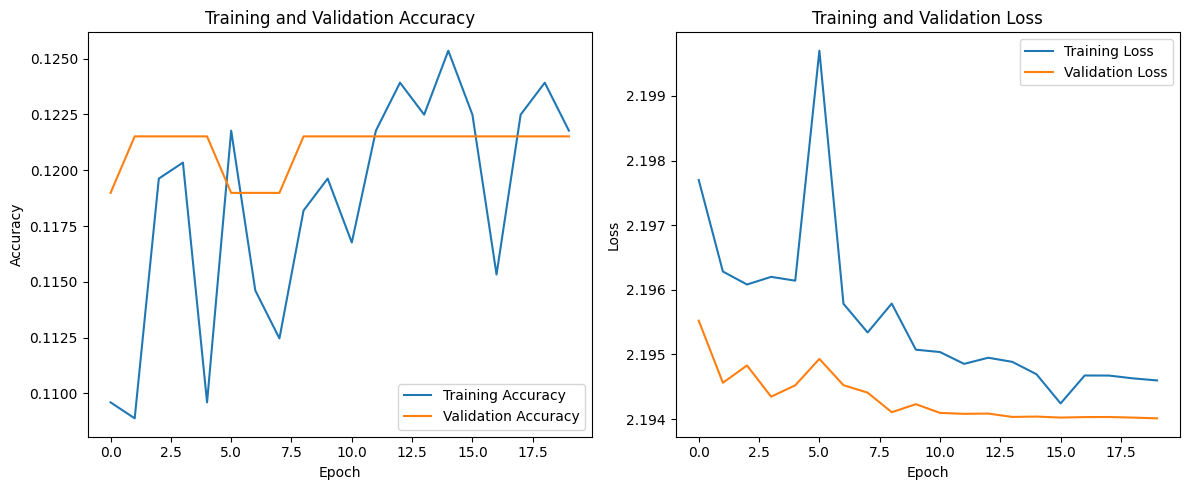


Evaluating model on the test set...
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 412ms/step - accuracy: 0.3191 - loss: 2.1675
Test Loss: 2.1950
Test Accuracy: 0.1221


In [ ]:
# --- 繪製訓練過程 ---
def plot_training_history(history_obj, include_validation=True):
    acc = history_obj.history['accuracy']
    loss = history_obj.history['loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    if include_validation and 'val_accuracy' in history_obj.history:
        val_acc = history_obj.history['val_accuracy']
        plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    if include_validation and 'val_loss' in history_obj.history:
        val_loss = history_obj.history['val_loss']
        plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.tight_layout()
    plt.show()

plot_training_history(history, include_validation=(validation_generator is not None))

# --- 在測試集上評估模型 (如果存在) ---
if test_generator:
    print("\nEvaluating model on the test set...")
    test_steps = math.ceil(test_generator.samples / batch_size)
    test_loss, test_accuracy = model.evaluate(test_generator, steps=test_steps, verbose=1)
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")
else:
    print("\nNo test set was provided or it was empty. Skipping final evaluation on test data.")

# --- 保存模型 (可選) ---
# model_save_path = os.path.join(base_dir, f'vgg19_roboflow_{num_classes}classes_model.keras')
# model.save(model_save_path)
# print(f"Model saved to {model_save_path}")

# 你也可以只保存權重
# weights_save_path = os.path.join(base_dir, f'vgg19_roboflow_{num_classes}classes_weights.weights.h5')
# model.save_weights(weights_save_path)
# print(f"Model weights saved to {weights_save_path}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # 用於繪製更美觀的混淆矩陣 (可選)
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import tensorflow as tf # 確保 TensorFlow 已導入
import math # 用於 ceil 計算 steps

# --- 假設這些變數已經在你之前的程式碼中定義好了 ---
# model = your_trained_model
# test_generator = your_test_data_generator (如果存在)
# num_classes = number_of_classes_in_your_dataset
# class_indices = train_generator.class_indices # 例如: {'class_a': 0, 'class_b': 1, ...}
# batch_size = your_batch_size

# --- 確保 test_generator 存在 ---
if test_generator is None:
    print("錯誤：test_generator 未定義或測試集不存在。無法計算混淆矩陣和 F1 分數。")
    # exit() # 或者根據你的情況處理
else:
    print("開始在測試集上進行評估以生成混淆矩陣和 F1 分數...")

    # 1. 獲取模型在測試集上的預測結果
    # 確保重置 test_generator 以從頭開始，並且 shuffle=False
    test_generator.reset()
    test_steps = math.ceil(test_generator.samples / batch_size)
    predictions_proba = model.predict(test_generator, steps=test_steps, verbose=1)

    # 2. 將預測結果轉換為最終的類別標籤 (整數索引)
    # predictions_proba 是一個形如 (num_samples, num_classes) 的數組，每行是屬於各個類的概率
    predicted_classes_indices = np.argmax(predictions_proba, axis=1)

    # 3. 獲取測試集的真實標籤 (整數索引)
    # test_generator.classes 會按順序返回所有樣本的真實類別索引
    true_classes_indices = test_generator.classes

    # 確保預測數量和真實標籤數量一致
    # ImageDataGenerator 有時最後一個批次可能不完整，但 predict 會處理所有 samples
    # 而 .classes 屬性會返回所有樣本的標籤
    if len(predicted_classes_indices) != len(true_classes_indices):
        print(f"警告：預測數量 ({len(predicted_classes_indices)}) 與真實標籤數量 ({len(true_classes_indices)}) 不匹配。")
        print("這可能是由於 test_generator 在 predict 結束後狀態未完全對應 .classes。")
        print("通常 .classes 是正確的，嘗試截斷預測以匹配。")
        # 這種情況較少發生，但如果發生，通常是 test_generator.samples 的問題
        # 但 predict(steps=test_steps) 應該會覆蓋所有 test_generator.samples
        # 更穩妥的方式是迭代 test_generator 獲取真實標籤，但 .classes 通常是準確的
        if len(predicted_classes_indices) > len(true_classes_indices):
             predicted_classes_indices = predicted_classes_indices[:len(true_classes_indices)]
        else: # 理論上不應該發生
             true_classes_indices = true_classes_indices[:len(predicted_classes_indices)]


    # 獲取類別標籤名稱 (用於報告和繪圖)
    # 我們需要按索引排序的類別名稱列表
    class_labels = list(class_indices.keys())
    # 確保 class_labels 的順序與 test_generator.classes 和 predicted_classes_indices 使用的索引一致
    # class_indices 是 {name: index}，我們需要一個 index -> name 的映射，或者一個按 index 排序的 name 列表
    # ImageDataGenerator 內部通常按字母順序排列類別來分配索引
    # 如果 class_indices 是 {'cat':0, 'dog':1}, 那麼 class_labels 應該是 ['cat', 'dog']
    # 為了保險，我們可以從 class_indices 構建
    sorted_class_labels = [None] * num_classes
    for class_name, index in class_indices.items():
        sorted_class_labels[index] = class_name

    if None in sorted_class_labels: # 簡單檢查
        print("警告：無法從 class_indices 正確構建 sorted_class_labels。將使用默認數字標籤。")
        target_names_for_report = [str(i) for i in range(num_classes)]
    else:
        target_names_for_report = sorted_class_labels


    # 4. 計算混淆矩陣
    cm = confusion_matrix(true_classes_indices, predicted_classes_indices)
    print("\n混淆矩陣 (Confusion Matrix):")
    print(cm)

    # 5. 可視化混淆矩陣
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names_for_report,
                yticklabels=target_names_for_report)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()

    # 6. 計算分類報告 (包含 Precision, Recall, F1-Score, Support)
    print("\n分類報告 (Classification Report):")
    report = classification_report(true_classes_indices, predicted_classes_indices, target_names=target_names_for_report, digits=4)
    print(report)

    # 7. 單獨計算不同平均方式的 F1 分數
    f1_macro = f1_score(true_classes_indices, predicted_classes_indices, average='macro')
    f1_micro = f1_score(true_classes_indices, predicted_classes_indices, average='micro')
    f1_weighted = f1_score(true_classes_indices, predicted_classes_indices, average='weighted')

    print(f"\nF1 Score (Macro): {f1_macro:.4f}")
    print(f"F1 Score (Micro): {f1_micro:.4f}") # Micro-F1 通常等於準確率 (accuracy)
    print(f"F1 Score (Weighted): {f1_weighted:.4f}")